# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">کتابخانه های مورد نیاز</div>

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">فراخوانی داده ها</div>

In [2]:
df = pd.read_csv('covtype.csv')
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">تحلیل اکتشافی داده ها </div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [4]:
df.iloc[:,:10].describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [5]:
df.iloc[:,10:54].astype('object').describe().T

,count,unique,top,freq
Wilderness_Area1,581012,2,0,320216
Wilderness_Area2,581012,2,0,551128
Wilderness_Area3,581012,2,0,327648
Wilderness_Area4,581012,2,0,544044
Soil_Type1,581012,2,0,577981
Soil_Type2,581012,2,0,573487
Soil_Type3,581012,2,0,576189
Soil_Type4,581012,2,0,568616
Soil_Type5,581012,2,0,579415
Soil_Type6,581012,2,0,574437


In [6]:
X = df.drop('Cover_Type',axis=1)
y = df['Cover_Type']

In [7]:
print('number of samples:',X.shape[0])
print('number of features:', X.shape[1])

number of samples: 581012
number of features: 54


In [8]:
df['Cover_Type'].astype('object').describe().T

count     581012
unique         7
top            2
freq      283301
Name: Cover_Type, dtype: int64

In [9]:
df['Cover_Type'].isna().sum()

0

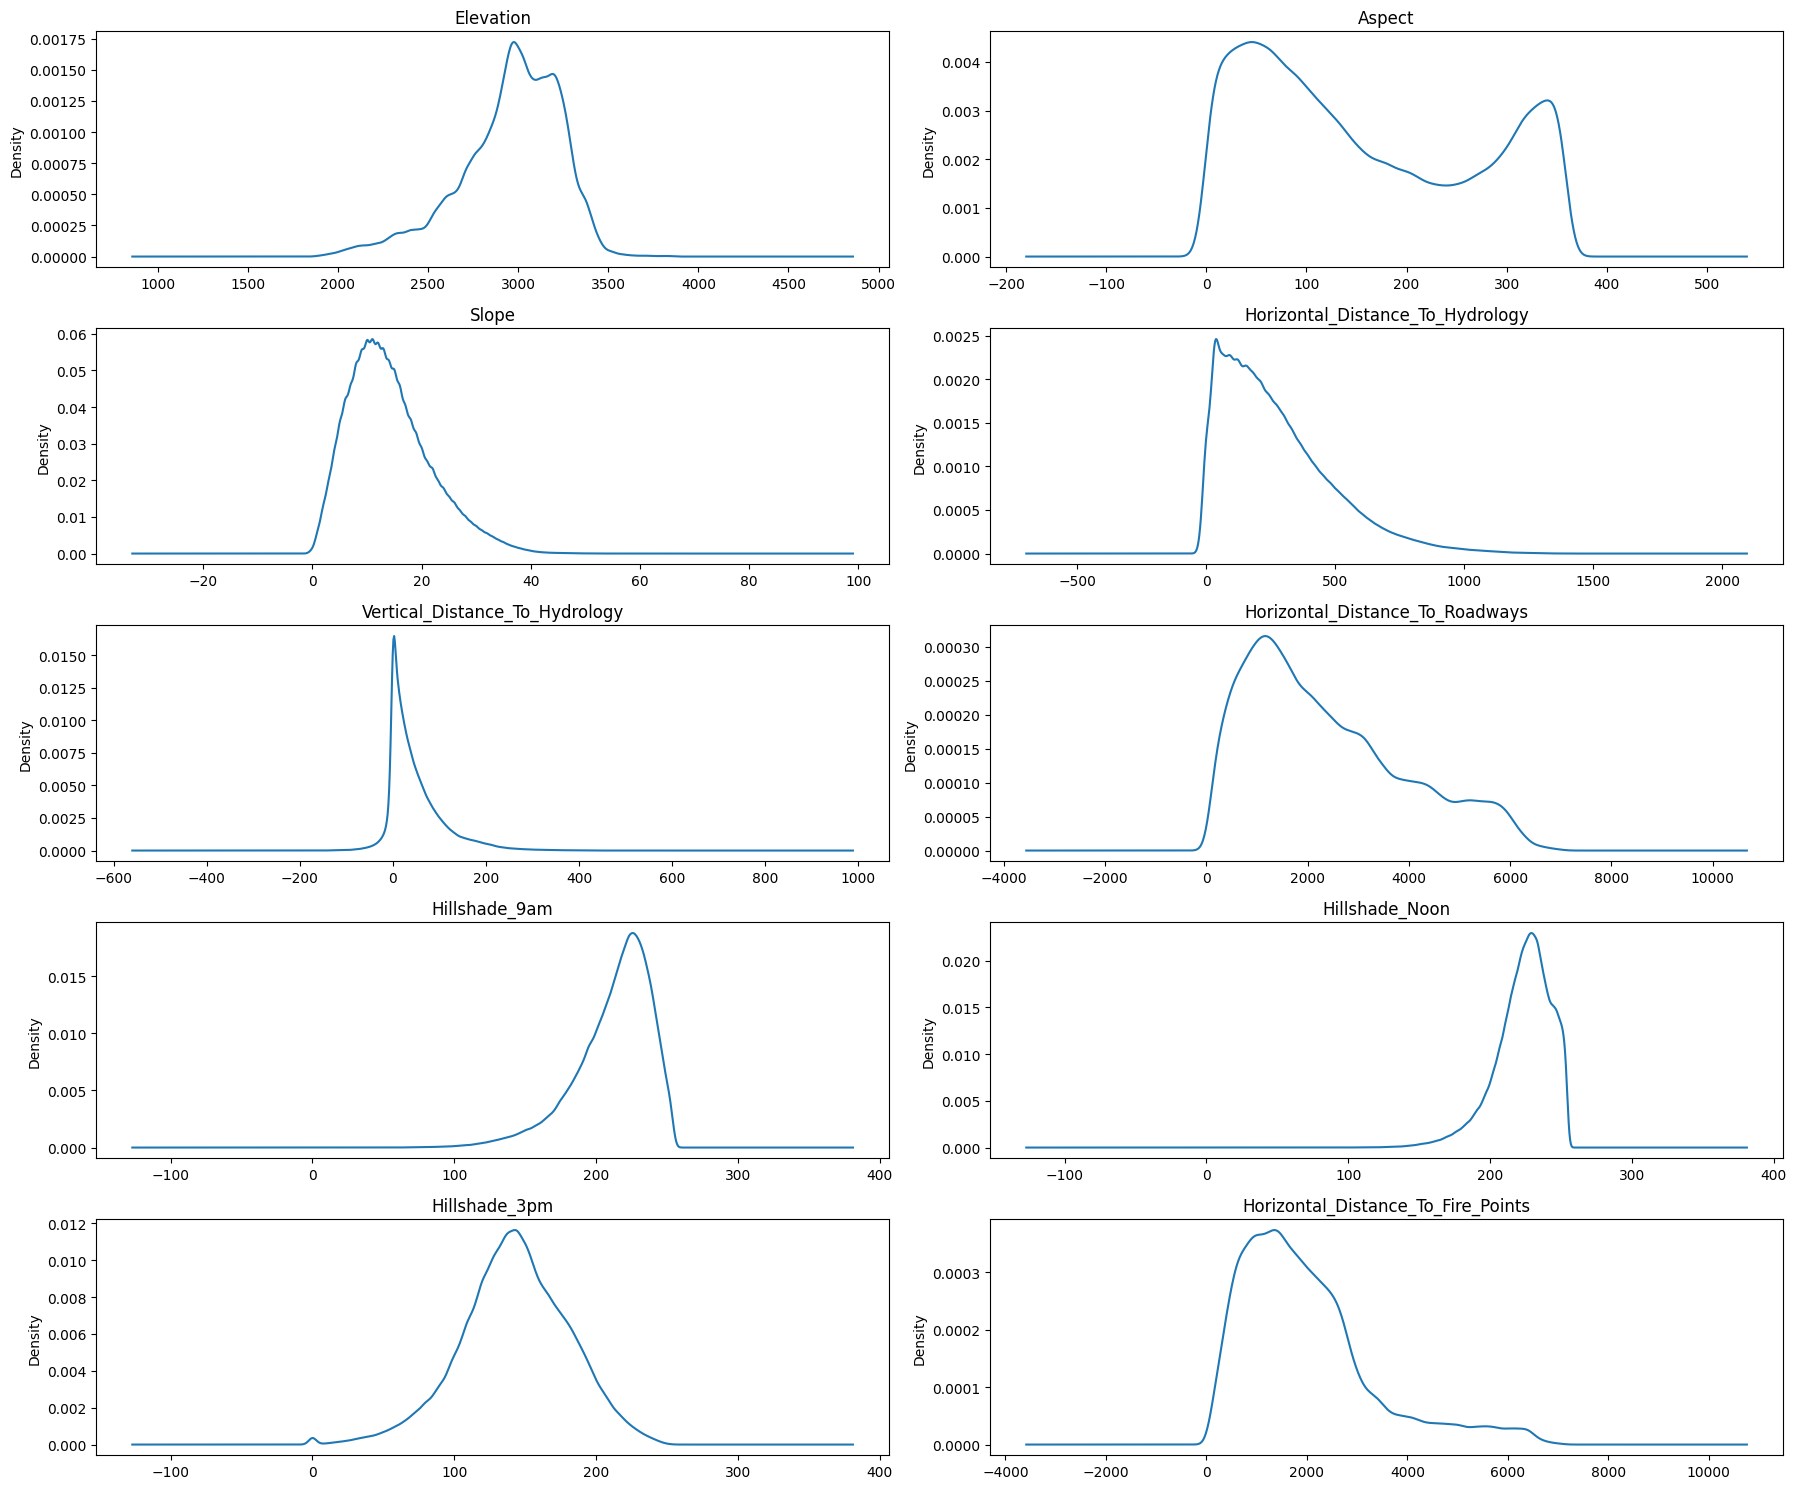

In [10]:
plt.figure(figsize=(18,15))
for i in range(10):
    ax = plt.subplot(5,2,i+1)
    df.iloc[:,i].plot(kind='kde',ax= ax)
    ax.set_title(df.columns[i])
plt.tight_layout()
plt.show()

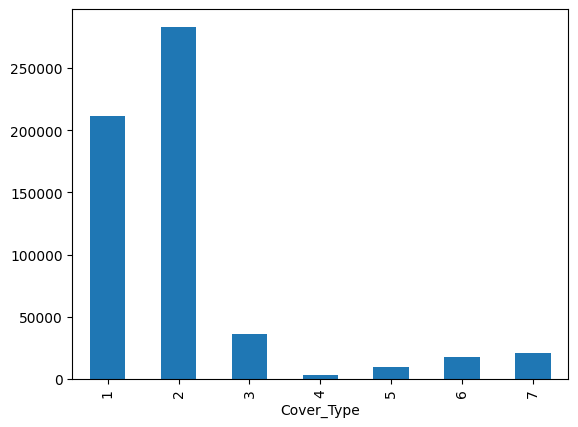

In [11]:
df['Cover_Type'].value_counts().sort_index().plot(kind='bar');

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">تقسیم داده ها به آموزشی و ارزیابی و آزمون</div>

In [12]:
X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.4,random_state=42 ,stratify=y)
X_test,X_val,y_test,y_val = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=y_temp)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">استاندارد سازی داده ها </div>

In [13]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std = scaler.transform(X_val)
X_test_std = scaler.transform(X_test)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;"><code>KNN</code></div>

In [14]:
k_values = [1,3,5,10,20,50]
train_acc = []
val_acc = []
for k in k_values:
    KNN  = KNeighborsClassifier(n_neighbors=k)
    KNN.fit(X_train_std,y_train)
    train_acc.append(KNN.score(X_train_std,y_train))
    val_acc.append(KNN.score(X_val_std,y_val))

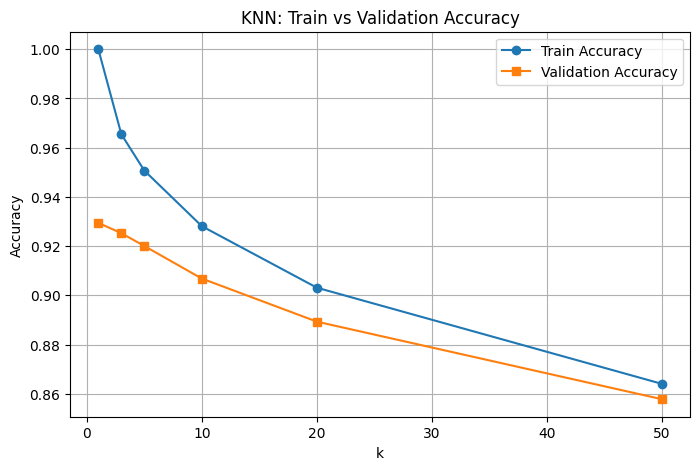

In [15]:
plt.figure(figsize=(8,5))
plt.plot(k_values,train_acc,marker = 'o',label = 'Train Accuracy')
plt.plot(k_values,val_acc,marker = 's',label = 'Validation Accuracy')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN: Train vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [16]:
k_values = [1, 3, 5, 10, 20, 50]
train_acc, val_acc, val_macro_f1 = [], [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)

    ytr = knn.predict(X_train_std)
    yva = knn.predict(X_val_std)

    train_acc.append(accuracy_score(y_train, ytr))
    val_acc.append(accuracy_score(y_val, yva))
    val_macro_f1.append(f1_score(y_val, yva, average="macro"))


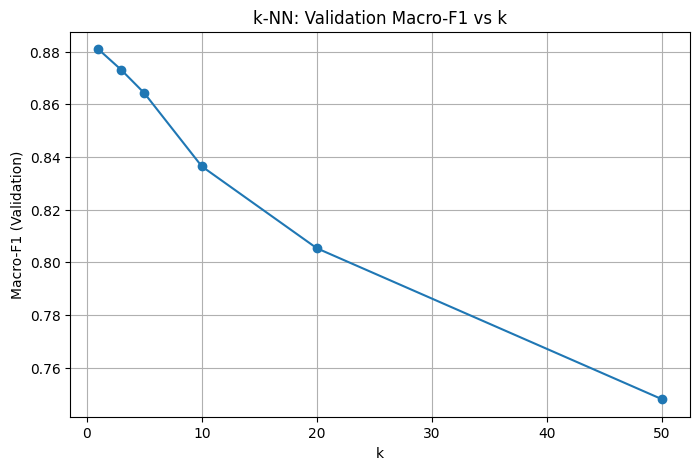

In [17]:
plt.figure(figsize=(8,5))
plt.plot(k_values, val_macro_f1, marker='o')
plt.xlabel("k")
plt.ylabel("Macro-F1 (Validation)")
plt.title("k-NN: Validation Macro-F1 vs k")
plt.grid()
plt.show()

In [18]:
best_k = 5
KNN_final = KNeighborsClassifier(n_neighbors=best_k)
KNN_final.fit(X_train_std,y_train)
y_pred_KNN_final = KNN_final.predict(X_test_std)
y_pred_KNN_final_val =KNN_final.predict(X_val_std) 

In [19]:
def print_metrics(split_name, y_true, y_pred):
    print(f"\n--- {split_name} ---")
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("misclassification_error:", 1 - accuracy_score(y_true, y_pred))
    print("precision (weighted):", precision_score(y_true, y_pred, average='weighted', zero_division=0))
    print("recall    (weighted):", recall_score(y_true, y_pred, average='weighted', zero_division=0))
    print("f1        (weighted):", f1_score(y_true, y_pred, average='weighted', zero_division=0))
    print("precision (macro):", precision_score(y_true, y_pred, average='macro', zero_division=0))
    print("recall    (macro):", recall_score(y_true, y_pred, average='macro', zero_division=0))
    print("f1        (macro):", f1_score(y_true, y_pred, average='macro', zero_division=0))

In [20]:
print_metrics("Validation", y_val, y_pred_KNN_final_val)
print_metrics("Test", y_test, y_pred_KNN_final)


--- Validation ---
accuracy: 0.9200278822405618
misclassification_error: 0.07997211775943824
precision (weighted): 0.9197092984253203
recall    (weighted): 0.9200278822405618
f1        (weighted): 0.9197462969327287
precision (macro): 0.8806610256194566
recall    (macro): 0.8498710267896463
f1        (macro): 0.8642416599492784

--- Test ---
accuracy: 0.9205435362558304
misclassification_error: 0.07945646374416959
precision (weighted): 0.920279810570622
recall    (weighted): 0.9205435362558304
f1        (weighted): 0.9203079599355926
precision (macro): 0.8773755504879748
recall    (macro): 0.8452187958755754
f1        (macro): 0.8601632167661876


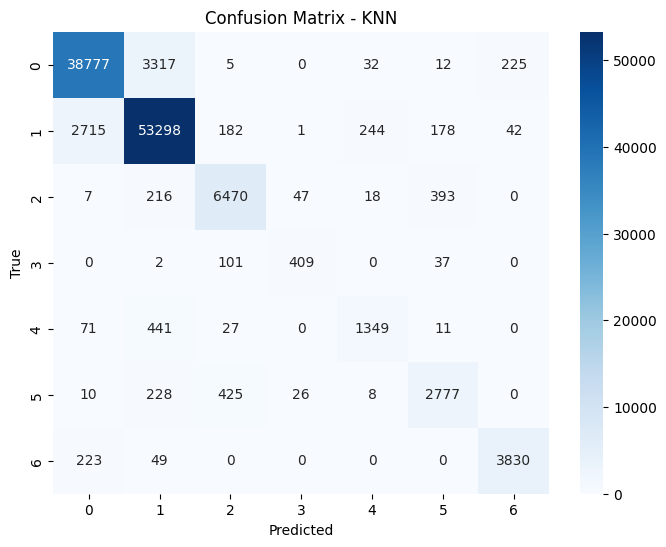

In [22]:
cm_knn = confusion_matrix(y_val, y_pred_KNN_final_val)
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, fmt='d',annot=True, cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;"><code>Decision Tree</code></div>

In [23]:
depths = [2,4,8,12,20]
train_acc_dt = []
val_acc_dt = []
for d in depths :
    dt = DecisionTreeClassifier(criterion='entropy',max_depth=d,random_state=42)
    dt.fit(X_train_std,y_train)
    train_acc_dt.append(dt.score(X_train_std,y_train))
    val_acc_dt.append(dt.score(X_val_std,y_val))

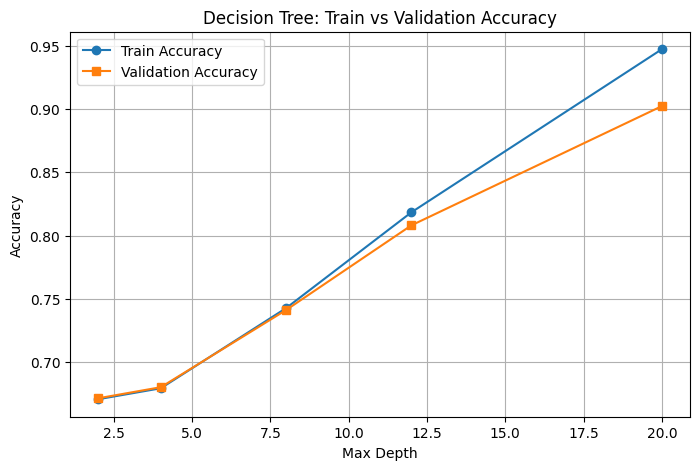

In [24]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc_dt, marker='o', label='Train Accuracy')
plt.plot(depths, val_acc_dt, marker='s', label='Validation Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

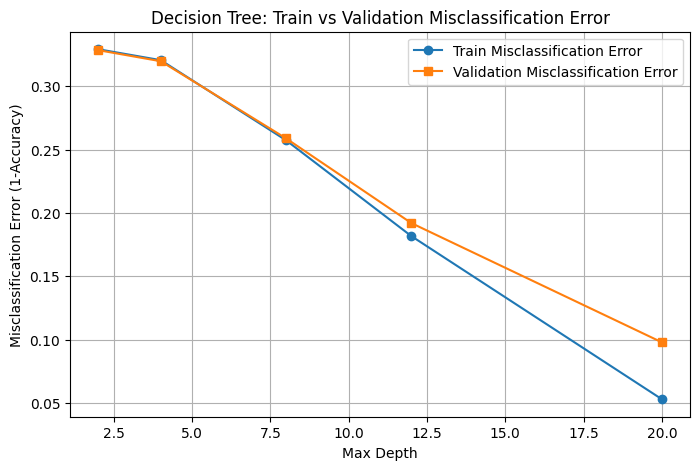

In [25]:
train_err_dt = [1 - a for a in train_acc_dt]
val_err_dt   = [1 - a for a in val_acc_dt]
plt.figure(figsize=(8,5))
plt.plot(depths, train_err_dt, marker='o', label='Train Misclassification Error')
plt.plot(depths, val_err_dt, marker='s', label='Validation Misclassification Error')
plt.xlabel("Max Depth")
plt.ylabel("Misclassification Error (1-Accuracy)")
plt.title("Decision Tree: Train vs Validation Misclassification Error")
plt.legend()
plt.grid()
plt.show()

In [26]:
best_dephts = 12
best_dt = DecisionTreeClassifier(max_depth=best_dephts,random_state=42,criterion='entropy')
best_dt.fit(X_train_std,y_train)
y_pred_dt_best_val = best_dt.predict(X_val_std)
y_pred_dt_best = best_dt.predict(X_test_std)

In [27]:
print_metrics("Validation", y_val, y_pred_dt_best_val)
print_metrics("Test", y_test, y_pred_dt_best)


--- Validation ---
accuracy: 0.8080342159840967
misclassification_error: 0.19196578401590325
precision (weighted): 0.8078718007291693
recall    (weighted): 0.8080342159840967
f1        (weighted): 0.8063703174730125
precision (macro): 0.8100909903626444
recall    (macro): 0.7064636354960695
f1        (macro): 0.7446399581320929

--- Test ---
accuracy: 0.8062770003958624
misclassification_error: 0.19372299960413764
precision (weighted): 0.8065162717980628
recall    (weighted): 0.8062770003958624
f1        (weighted): 0.8049350288975451
precision (macro): 0.8121798647784819
recall    (macro): 0.7141394031070548
f1        (macro): 0.750819473860705


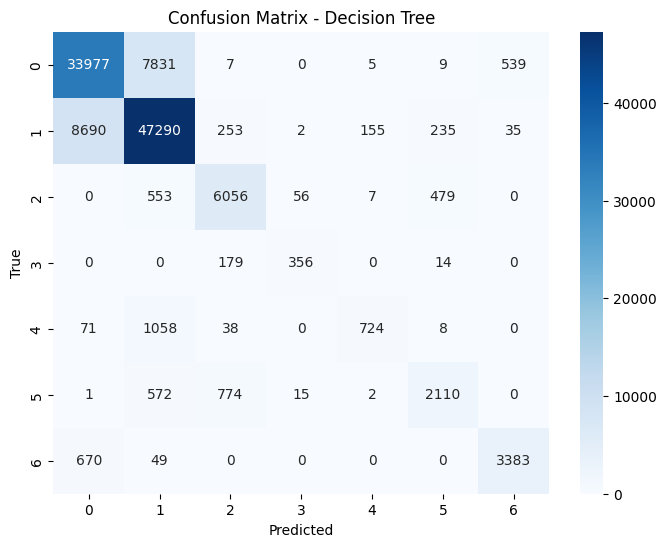

In [28]:
cm_dt = confusion_matrix(y_val, y_pred_dt_best_val)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, fmt='d',annot=True, cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;"><code>LDA</code></div>

In [29]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train_std, y_train)
print("Train Accuracy:", lda.score(X_train_std, y_train))
print("Validation Accuracy:", lda.score(X_val_std, y_val))
print("Test Accuracy:", lda.score(X_test_std, y_test))

Train Accuracy: 0.6795933529734056
Validation Accuracy: 0.6815142466201389
Test Accuracy: 0.6783273953976696


In [30]:
y_pred_test_lda = lda.predict(X_test_std)
y_pred_val_lda = lda.predict(X_val_std)
print_metrics("Validation", y_val, y_pred_val_lda)
print_metrics("Test", y_test, y_pred_test_lda)


--- Validation ---
accuracy: 0.6815142466201389
misclassification_error: 0.31848575337986107
precision (weighted): 0.6966690684181749
recall    (weighted): 0.6815142466201389
f1        (weighted): 0.6847364250328296
precision (macro): 0.485564343047068
recall    (macro): 0.5765813835916523
f1        (macro): 0.5095632105130936

--- Test ---
accuracy: 0.6783273953976696
misclassification_error: 0.3216726046023304
precision (weighted): 0.69313459363131
recall    (weighted): 0.6783273953976696
f1        (weighted): 0.6812729504609462
precision (macro): 0.4838422157076909
recall    (macro): 0.5734324664536502
f1        (macro): 0.5058834959493724


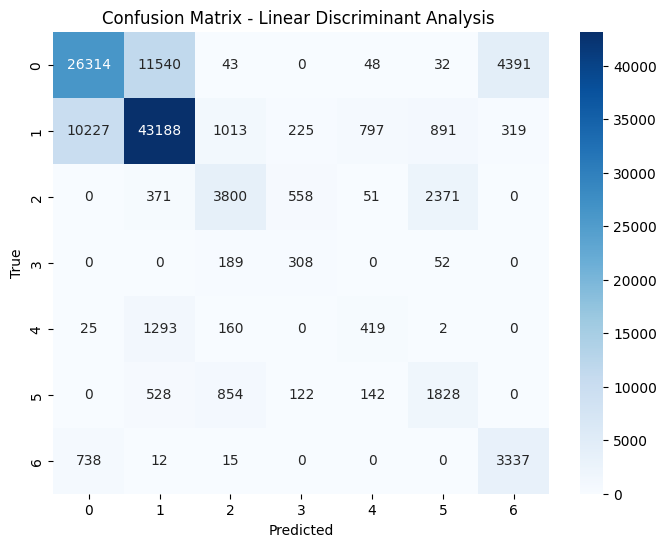

In [31]:
cm_lda = confusion_matrix(y_val, y_pred_val_lda)
plt.figure(figsize=(8,6))
sns.heatmap(cm_lda, fmt='d',annot=True, cmap="Blues")
plt.title("Confusion Matrix - Linear Discriminant Analysis ")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ارزیابی مدل ها </div>

In [32]:
def _metrics(y_true, y_pred):
    return {
        "macro_f1": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average='macro', zero_division=0),

        "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),

        "accuracy": accuracy_score(y_true, y_pred),
    }

def add_row(rows, model_name, best_param, y_train, y_pred_train, y_test, y_pred_test):
    tr = _metrics(y_train, y_pred_train)
    te = _metrics(y_test, y_pred_test)

    rows.append({
        ("Model", ""): model_name,
        ("Best Param", ""): best_param,

        ("Macro-F1", "train"): tr["macro_f1"],
        ("Macro-F1", "test"):  te["macro_f1"],

        ("Macro-Recall", "train"): tr["macro_recall"],
        ("Macro-Recall", "test"):  te["macro_recall"],

        ("Macro-Precision", "train"): tr["macro_precision"],
        ("Macro-Precision", "test"):  te["macro_precision"],

        ("F1-Score", "train"): tr["f1"],
        ("F1-Score", "test"):  te["f1"],

        ("Recall", "train"): tr["recall"],
        ("Recall", "test"):  te["recall"],

        ("Precision", "train"): tr["precision"],
        ("Precision", "test"):  te["precision"],

        ("Accuracy", "train"): tr["accuracy"],
        ("Accuracy", "test"):  te["accuracy"],
    })
y_pred_train_knn = KNN_final.predict(X_train_std)
y_pred_test_knn  = KNN_final.predict(X_test_std)   
y_pred_train_dt = best_dt.predict(X_train_std)
y_pred_test_dt  = best_dt.predict(X_test_std)      
y_pred_train_lda = lda.predict(X_train_std)
y_pred_test_lda  = lda.predict(X_test_std)

rows = []
add_row(rows, "k-NN", f"k={best_k}", y_train, y_pred_train_knn, y_test, y_pred_test_knn)
add_row(rows, "decision tree", f"max_depth={best_dephts}", y_train, y_pred_train_dt, y_test, y_pred_test_dt)
add_row(rows, "LDA", "-", y_train, y_pred_train_lda, y_test, y_pred_test_lda)

df_final = pd.DataFrame(rows)
df_final.columns = pd.MultiIndex.from_tuples(df_final.columns)

order = ["Model", "Best Param",
         "Macro-F1", "Macro-Recall", "Macro-Precision",
         "F1-Score", "Recall", "Precision", "Accuracy"]
df_final = df_final[[col for key in order for col in df_final.columns if col[0] == key]]
df_final = df_final.round(4)
df_final

Model    Best Param Macro-F1         Macro-Recall          \
                                  train    test        train    test   
0           k-NN           k=5   0.9147  0.8602       0.9032  0.8452   
1  decision tree  max_depth=12   0.7802  0.7508       0.7385  0.7141   
2            LDA             -   0.5105  0.5059       0.5789  0.5734   

  Macro-Precision         F1-Score          Recall         Precision          \
            train    test    train    test   train    test     train    test   
0          0.9274  0.8774   0.9506  0.9203  0.9507  0.9205    0.9506  0.9203   
1          0.8478  0.8122   0.8172  0.8049  0.8183  0.8063    0.8190  0.8065   
2          0.4874  0.4838   0.6828  0.6813  0.6796  0.6783    0.6949  0.6931   

  Accuracy          
     train    test  
0   0.9507  0.9205  
1   0.8183  0.8063  
2   0.6796  0.6783